In [47]:
# install split-folders
!pip install split-folders

In [48]:
# Import libraries

import os
import glob
import shutil
import kagglehub
import splitfolders
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from google.colab import drive
from PIL import Image
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

In [49]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
# # Download dataset from kaggle
# path = kagglehub.dataset_download("shijo96john/facial-skin-acne-pigmentation-pores-wrinkles")

# print("Path to dataset files:", path)

In [51]:
# define path directory
path = '/content/drive/MyDrive/Final project'
main_path = os.path.join(path, 'Dataset')
acne = os.path.join(main_path, 'acne')
blackheads = os.path.join(main_path, 'blackheads')
dark_spots = os.path.join(main_path, 'dark spots')
pores = os.path.join(main_path, 'pores')
wrinkles = os.path.join(main_path, 'wrinkles')

In [52]:
# buat list class
label_dict = {'acne': acne, 'blackheads': blackheads, 'dark_spots': dark_spots, 'pores': pores, 'wrinkles': wrinkles}

# buat function hitung jumlah data kelas
def checkpath(labels):
  '''fungsi ini berguna untuk menghitung jumlah data dari masing-masing kelas'''
  for label in labels:
    num_path = len(os.listdir(labels[label]))
    print(f'Total data {label}: {num_path}')

checkpath(label_dict)

Total data acne: 314
Total data blackheads: 248
Total data dark_spots: 207
Total data pores: 251
Total data wrinkles: 207


In [53]:
# buat function untuk rename data
def rename(labels):
  '''fungsi ini berguna untuk mengganti nama data lalu mengcopy-nya ke path baru agar bisa dilakukan transformasi data'''
  output_root = '/dataset'
  for label in labels:
    path = labels[label]
    label_files = glob.glob(os.path.join(path, '*'))
    dest_path = os.path.join(output_root, label)
    os.makedirs(dest_path, exist_ok=True)
    num = 1
    for file in label_files:
      try:
        with Image.open(file) as img:
          fmt = img.format
      except Exception as e:
        print(f"Skip {file}: {e}")
        continue

      if fmt == 'JPEG':
        ext = 'jpg'
      elif fmt == 'PNG':
        ext = 'png'
      elif fmt == 'WEBP':
        ext = 'webp'
      else:
        print(f"Skip {file}: format {fmt} tidak didukung")
        continue

      new_name = f'{label}_{num:03d}.{ext}'
      new_file_path = os.path.join(dest_path, new_name)
      shutil.copy(file, new_file_path)
      num += 1

rename(label_dict)

In [54]:
# define path directory
main_path = '/dataset'
acne = os.path.join(main_path, 'acne')
blackheads = os.path.join(main_path, 'blackheads')
dark_spots = os.path.join(main_path, 'dark_spots')
pores = os.path.join(main_path, 'pores')
wrinkles = os.path.join(main_path, 'wrinkles')

# buat list class
label_dict = {'acne': acne, 'blackheads': blackheads, 'dark_spots': dark_spots, 'pores': pores, 'wrinkles': wrinkles}

Class: acne


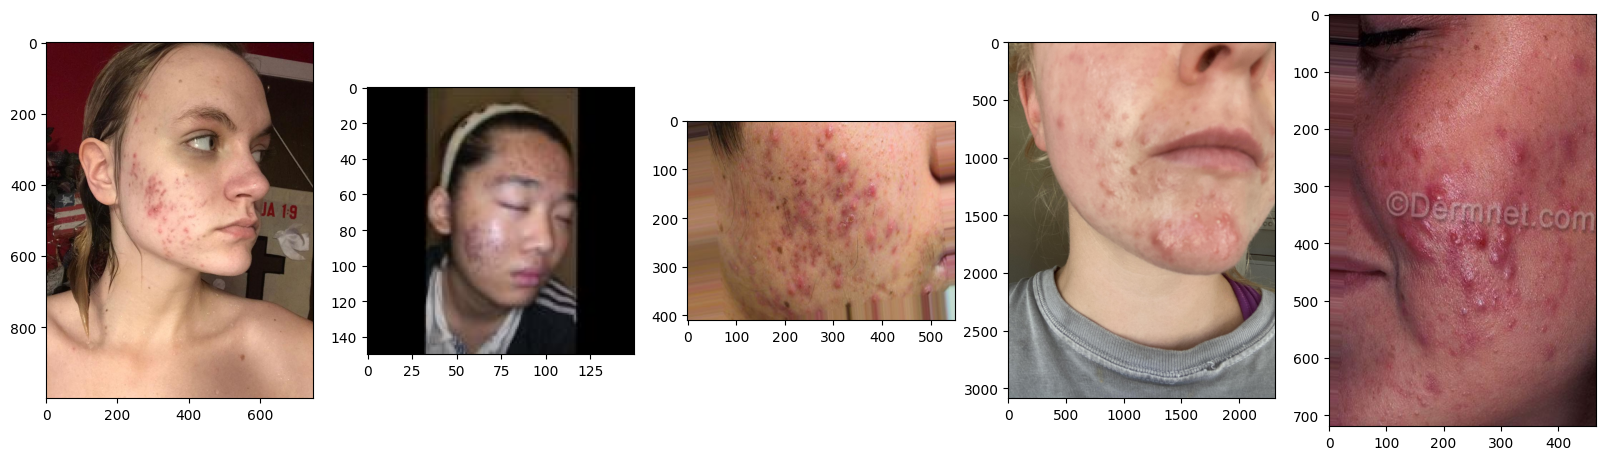

Class: blackheads


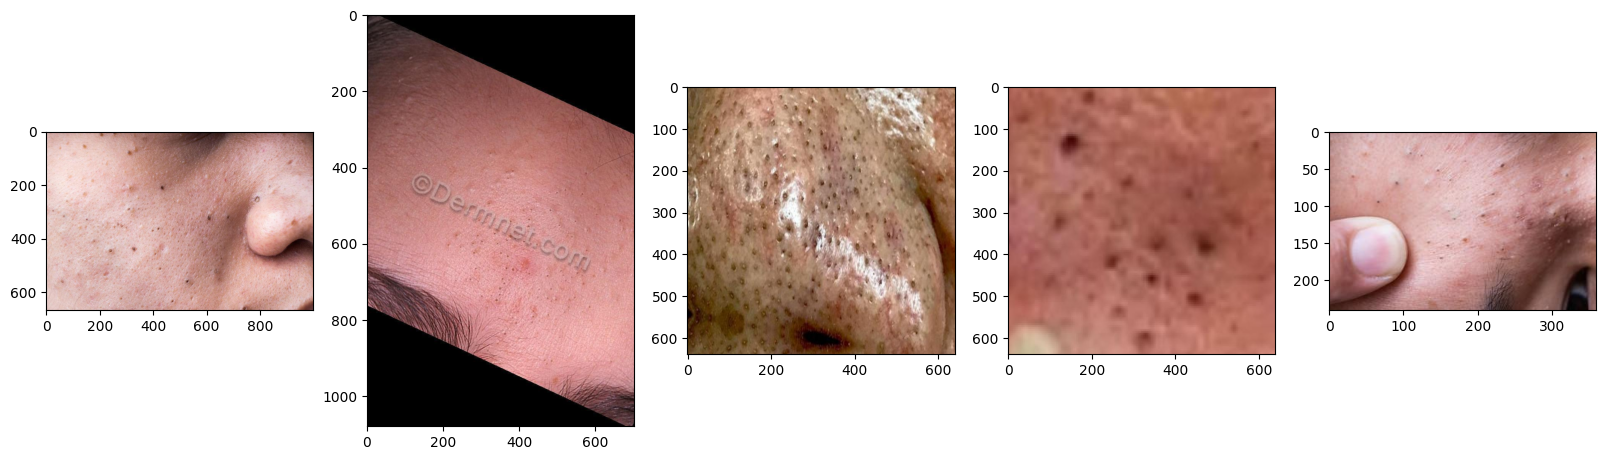

Class: dark_spots


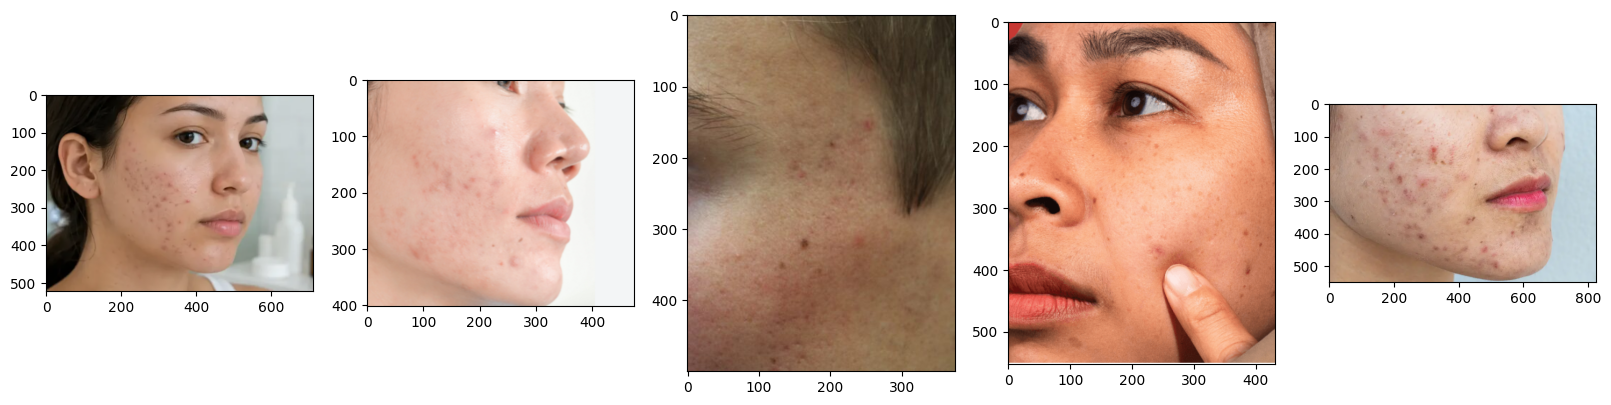

Class: pores


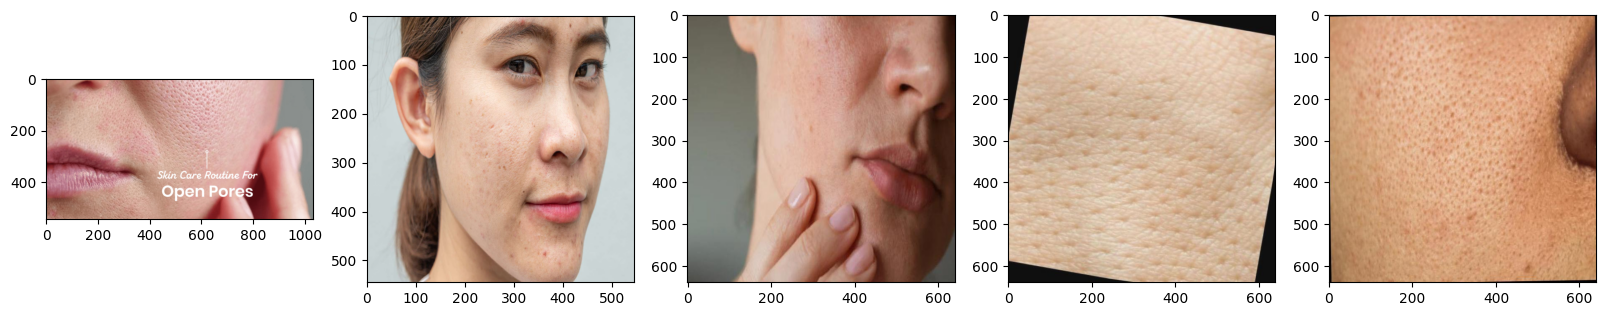

Class: wrinkles


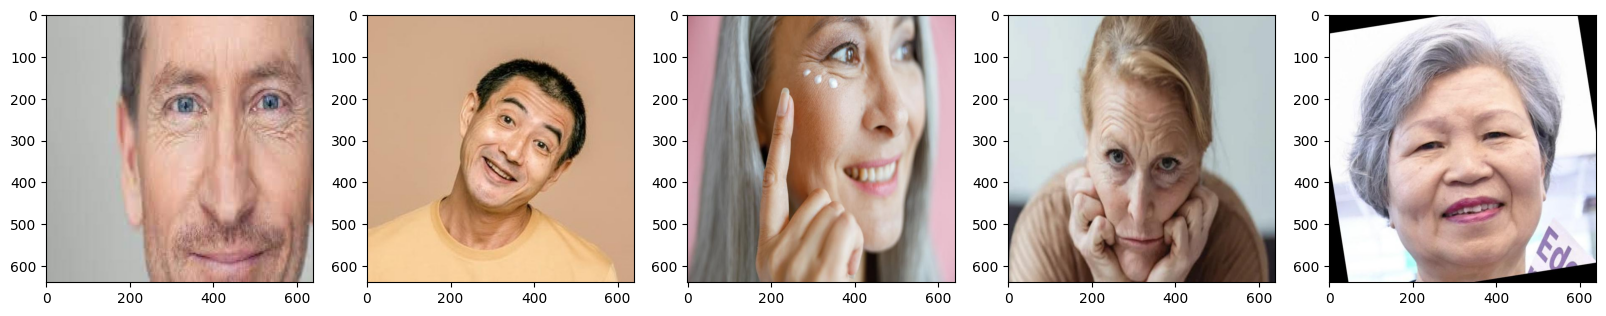

In [55]:
# buat function untuk menampilkan 5 gambar dari masing-masing kelas
def show_images(labels):
  '''fungsi ini berguna untuk menampilkan 5 gambar pertama dari masing-masing kelas'''
  for label in labels:
    fig = plt.figure(figsize=(20,20))
    col = 5
    row = 1
    print('Class:', label)
    images = os.listdir(labels[label])
    for index in range(1, col*row+1):
      fig.add_subplot(row, col, index)
      image = Image.open(os.path.join(labels[label], images[index])).convert('RGB')
      plt.imshow(image)
    plt.show()

show_images(label_dict)


In [56]:
# Define hyperparameters

img_height= 150
img_width= 150
batch_size= 64

In [57]:
# buat main path baru
main_path = '/dataset'

# lakukan split folder otomatis untuk train, val, dan test
splitfolders.ratio(main_path, output = 'preprocessed', seed = 9, ratio = (0.8, 0.1, 0.1))

# load data train
train_set = tf.keras.utils.image_dataset_from_directory(
    'preprocessed/train',
    image_size = (img_height, img_width),
    batch_size = batch_size,
    label_mode = 'categorical'
)

# load data val
val_set = tf.keras.utils.image_dataset_from_directory(
    'preprocessed/val',
    image_size = (img_height, img_width),
    batch_size = batch_size,
    label_mode = 'categorical'
)

# load data test
test_set = tf.keras.utils.image_dataset_from_directory(
    'preprocessed/test',
    image_size = (img_height, img_width),
    batch_size = batch_size,
    label_mode = 'categorical',
    shuffle = False
)


Copying files: 1227 files [00:00, 2003.07 files/s]

Found 931 files belonging to 5 classes.
Found 114 files belonging to 5 classes.
Found 124 files belonging to 5 classes.


In [58]:
# Show labels

classes = train_set.class_names

class_indices = pd.DataFrame(
    [[index, class_name] for index, class_name in enumerate(classes)],
    columns = ['index', 'class name']
)

class_indices.style.hide(axis='index')

index,class name
0,acne
1,blackheads
2,dark_spots
3,pores
4,wrinkles


In [59]:
# set autotune and prefetch
AUTOTUNE = tf.data.AUTOTUNE

train_set = train_set.cache().prefetch(buffer_size=AUTOTUNE)
val_set = val_set.cache().prefetch(buffer_size=AUTOTUNE)
test_set = test_set.cache().prefetch(buffer_size=AUTOTUNE)

In [60]:
# buat layer feature engineering
feature_engineering = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

In [61]:
# Clear session

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [62]:
# buat model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    feature_engineering,
    tf.keras.layers.Conv2D(12, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(12, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(12, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(12, activation='relu'),
    tf.keras.layers.Dense(5, activation = 'sigmoid')
])

In [63]:
# Compile
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 12)   │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 12)     │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 12)     │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3468)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3468)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │        41,628 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,645 (174.39 KB)

 Trainable params: 44,645 (174.39 KB)

 Non-trainable params: 0 (0.00 B)

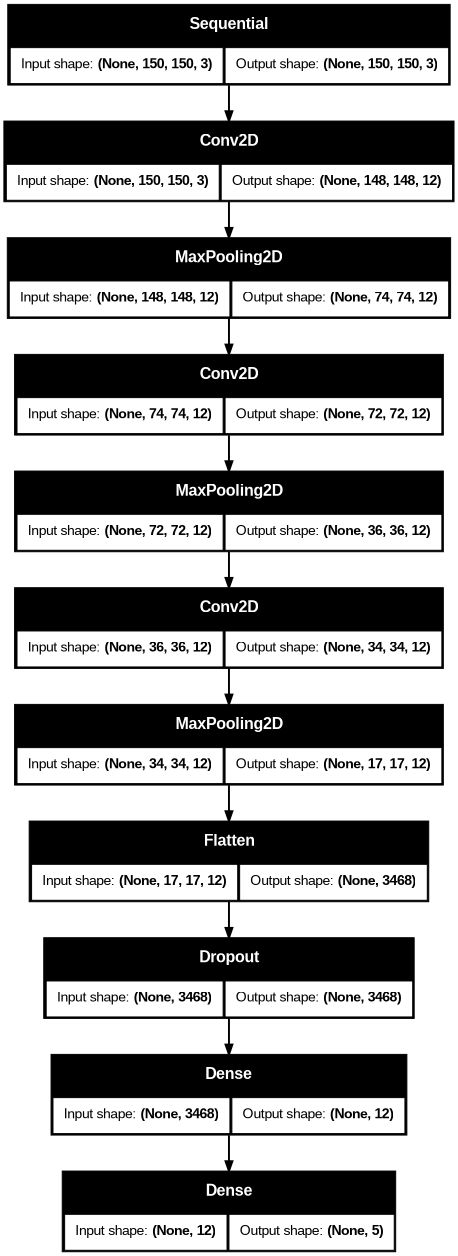

In [64]:
# plot model
tf.keras.utils.plot_model(model, show_shapes=True, dpi=70)

In [65]:
# Train model

%%time
history_model = model.fit(
    train_set,
    validation_data=val_set,
    epochs=30,
    batch_size=batch_size
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.1826 - loss: 0.5388 - val_accuracy: 0.2018 - val_loss: 0.5046
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2385 - loss: 0.5053 - val_accuracy: 0.2632 - val_loss: 0.5002
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2567 - loss: 0.5009 - val_accuracy: 0.2632 - val_loss: 0.4970
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2653 - loss: 0.4990 - val_accuracy: 0.2719 - val_loss: 0.4950
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2642 - loss: 0.4968 - val_accuracy: 0.2719 - val_loss: 0.4918
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2642 - loss: 0.4952 - val_accuracy: 0.3333 - val_loss: 0.4907
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2707 - loss: 0.4917 - val_accuracy: 0.3158 - val_loss: 0.4877
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2621 - loss: 0.4906 - val_accuracy: 0.3158 - 

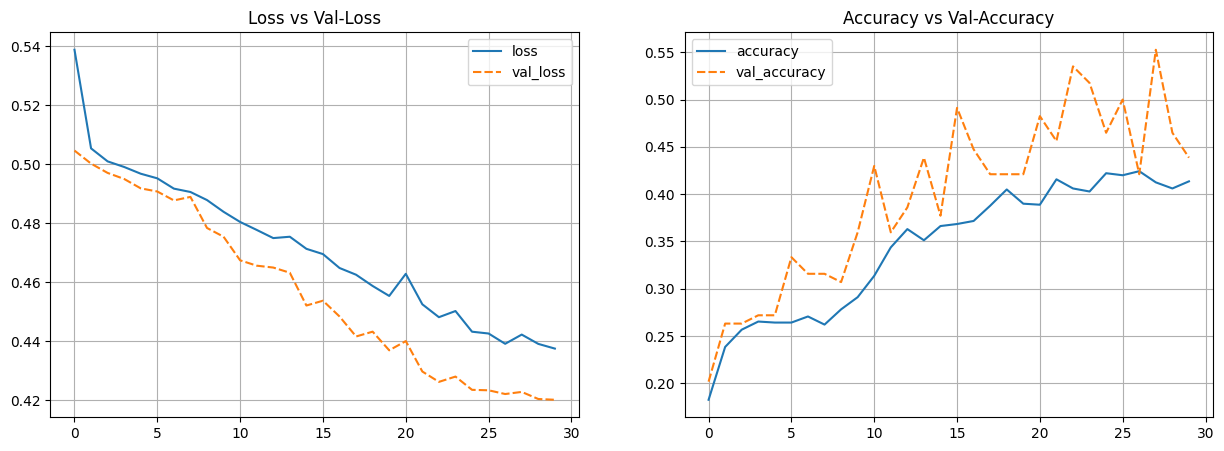

In [66]:
# buat dataframe history
history_df = pd.DataFrame(history_model.history)

# buat plot loss
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.lineplot(data = history_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

# buat plot accuracy
plt.subplot(1,2,2)
sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')

plt.show()

In [67]:
# Check the performance of test-set

## Get the probability
y_pred_prob = model.predict(test_set)

## Get class with maximum probability
y_pred_class = np.argmax(y_pred_prob, axis=1)

test_set_class = np.concatenate([label.numpy() for image, label in test_set], axis=0)
print(test_set_class.shape)
test_set_class = np.argmax(test_set_class, axis=1)  # only if it's currently one-hot from the same pipeline

## Display Classification Report
print(classification_report(test_set_class, y_pred_class, target_names=classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 403ms/step
(124, 5)
              precision    recall  f1-score   support

        acne       0.34      0.44      0.38        32
  blackheads       0.20      0.04      0.06        26
  dark_spots       0.00      0.00      0.00        19
       pores       0.33      0.80      0.47        25
    wrinkles       0.65      0.50      0.56        22

    accuracy                           0.37       124
   macro avg       0.30      0.36      0.30       124
weighted avg       0.31      0.37      0.31       124



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Model 2

In [68]:
img_height = 224
img_width = 224

# buat feature engineering layer baru
feature_engineering_2 = tf.keras.Sequential([
    tf.keras.layers.Resizing(img_height, img_width),
    tf.keras.layers.Rescaling(1./127.5, offset= -1),
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
])

In [69]:
# Clear session

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [70]:
# panggil pretrained model MobileNetV2
pretrained = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=(img_height, img_width, 3),
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    include_preprocessing=False,
    name="efficientnetv2-b0",
)

# ganti semua trainable menjadi False
pretrained.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [71]:
# define model baru dengan feature engineering layer baru dan pretrained model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),
    feature_engineering_2,
    pretrained,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation = 'sigmoid')
])

In [72]:
# Compile
model_2.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,960,469 (22.74 MB)

 Trainable params: 41,157 (160.77 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

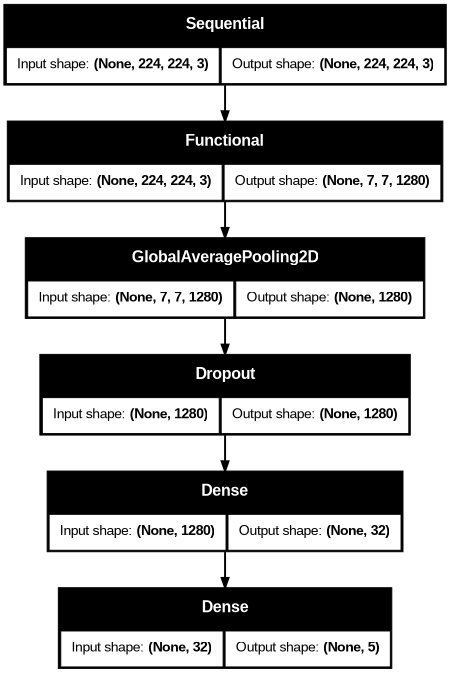

In [73]:
# plot model
tf.keras.utils.plot_model(model_2, show_shapes=True, dpi=70)

In [74]:
# Train the model

%%time
history_model2 = model_2.fit(
    train_set,
    validation_data=val_set,
    epochs=80,
    batch_size=batch_size
)

Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 430ms/step - accuracy: 0.3319 - loss: 0.5346 - val_accuracy: 0.5526 - val_loss: 0.4095
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.5220 - loss: 0.4092 - val_accuracy: 0.6754 - val_loss: 0.3485
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.6026 - loss: 0.3668 - val_accuracy: 0.6930 - val_loss: 0.3086
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.6584 - loss: 0.3319 - val_accuracy: 0.7281 - val_loss: 0.2769
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.7100 - loss: 0.2980 - val_accuracy: 0.7456 - val_loss: 0.2558
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.7111 - loss: 0.2851 - val_accuracy: 0.7807 - val_loss: 0.2414
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.7422 - loss: 0.2679 - val_accuracy: 0.8158 - val_loss: 0.2291
Epoch 8/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.7508 - loss: 0.2581 - val_accuracy: 0

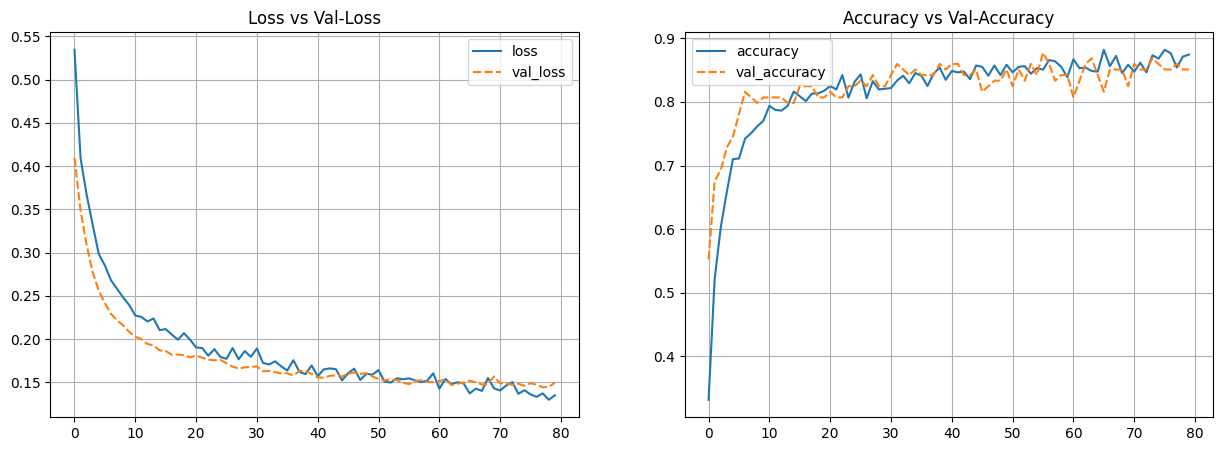

In [75]:
# buat dataframe history
history_df = pd.DataFrame(history_model2.history)

# buat plot loss
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.lineplot(data = history_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss')

# buat plot accuracy
plt.subplot(1,2,2)
sns.lineplot(data=history_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy')

plt.show()

In [76]:
# Check the performance of test-set

## Get the probability
y_pred_prob = model_2.predict(test_set)

## Get class with maximum probability
y_pred_class = np.argmax(y_pred_prob, axis=1)

test_set_class = np.concatenate([label.numpy() for image, label in test_set], axis=0)
print(test_set_class.shape)
test_set_class = np.argmax(test_set_class, axis=1)  # only if it's currently one-hot from the same pipeline

## Display Classification Report
print(classification_report(test_set_class, y_pred_class, target_names=classes))

1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 4s/step
(124, 5)
              precision    recall  f1-score   support

        acne       0.84      0.97      0.90        32
  blackheads       0.92      0.85      0.88        26
  dark_spots       0.73      0.42      0.53        19
       pores       0.73      0.96      0.83        25
    wrinkles       1.00      0.86      0.93        22

    accuracy                           0.84       124
   macro avg       0.84      0.81      0.81       124
weighted avg       0.84      0.84      0.83       124



In [77]:
# save model
model_2.save('model_2.keras')
model.save('model.keras')